# Full pipeline for preprosessing, labeling and segmenting a test file set

### Imports

In [1]:
from pre_processing.labeling import detect_spikes, init_label, plot_signal_peaks, extract_activity_windows, apply_corrected_labels, extract_pressure_data, remove_idle, sort_push_pull
from pre_processing.fiks_time_muse import make_df, check_samples, fix_time_muse_hz
from ploting.plot_gyr_axl_muse import plot_axl_muse, plot_gyro_muse, plot_mag_muse, plot_axl_muse_rotation
from ploting.plot_mitch import plot_gyro_axl_mitch, plot_press_soles, preassure_plots_average, preassure_plots_not_average
from pre_processing.segment_repetitions import make_segments, make_start_stop_segmentation_file, cut_repetitions_in_midle
from pre_processing.clean_mitch_timestamps import remove_end_duplicates, add_ReconstructedTime
from pre_processing.filter_sensor_data import median_filter_medfilt
from pre_processing.segment_repetition_vol2 import plot_activity_accelerations_peaks_and_magnitude, get_start_stop_times_from_peaks

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

### Define path to raw sensor files and output directory (same dir as test files is convention)

In [31]:
# Define path to arm sensor file (raw data)
raw_arm_path = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_master_maria\test_6\Muse_E2511_RED-upper_arm.txt"
raw_back_path = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_master_maria\test_6\Muse_E2511_GREY-lower_back.txt"
raw_left_path = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_master_maria\test_6\mitch_B0308-left_old_small.txt"
raw_right_path = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_master_maria\test_6\mitch_B0510-right_new_small.txt"

output_dir = Path(r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_master_maria\test_6")

### A sanity check, compare new raw data to Maria's data
At the early stage of my data collection, ensure that i have done it correctly, i.e. the sensors work the way they should and the raw time series look somewhat similar.

In [32]:
# Maria testfiles:
maria_arm = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_master_maria\test_5\Muse_E2511_RED-arm.txt"
maria_back = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_master_maria\test_5\Muse_E2511_GREY-back.txt"
maria_left = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_master_maria\test_5\mitch_B0510-new_left_small.txt"
maria_right = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_master_maria\test_5\mitch_B0308-old_right_small.txt"

DEBUG LENGTH PRINTS
544484
544484


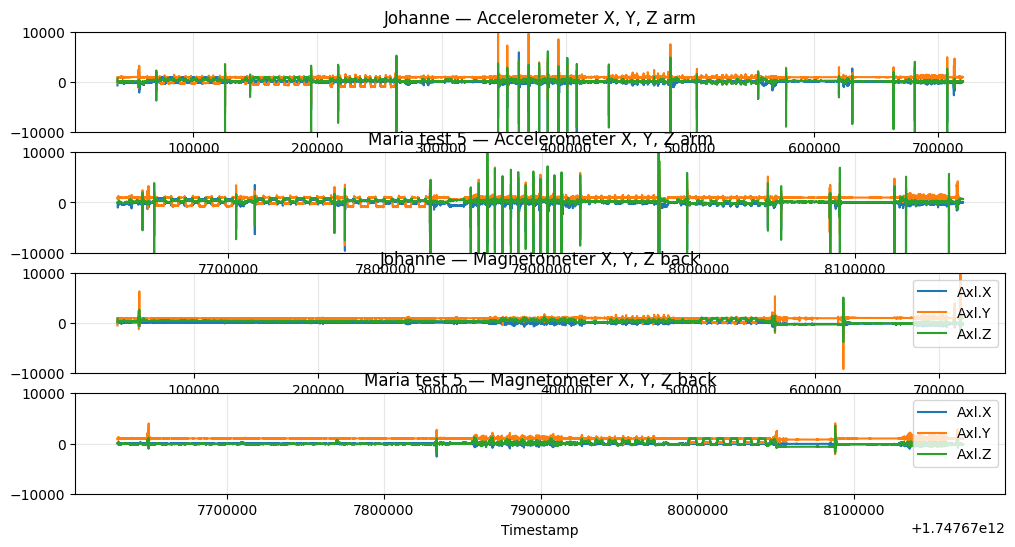

In [33]:
# Muse axl comparison
muse_dfs_j = make_df(muse_file_1=raw_arm_path, muse_file_2=raw_back_path)
muse_dfs_m = make_df(muse_file_1=maria_arm, muse_file_2=maria_back)

AX_COLS = ["Axl.X", "Axl.Y", "Axl.Z"]
MAG_COLS = ["Mag.X", "Mag.Y", "Mag.Z"]

x_j_arm = muse_dfs_j[0]["Timestamp"]
x_m_arm = muse_dfs_m[0]["Timestamp"]

x_j_back = muse_dfs_j[1]["Timestamp"]
x_m_back = muse_dfs_m[1]["Timestamp"]
# two subplots (stacked). use (1,2) for side-by-side
fig, axes = plt.subplots(4, 1, figsize=(12, 6), sharex=False, sharey=True)

print("DEBUG LENGTH PRINTS")
print(len(x_j_arm))
print(len(x_j_back))

for col in AX_COLS:
    axes[0].plot(x_j_arm, muse_dfs_j[0][col])
axes[0].set_title("Johanne — Accelerometer X, Y, Z arm")
axes[0].set_xlabel("Timestamp")
#axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

for col in AX_COLS:
    axes[2].plot(x_j_back, muse_dfs_j[1][col], label=col)
axes[2].set_title("Johanne — Magnetometer X, Y, Z back")
axes[2].set_xlabel("Timestamp")
#axes[0].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(-10000, 10000)
axes[2].legend(loc='upper right')


for col in AX_COLS:
    axes[1].plot(x_m_arm, muse_dfs_m[0][col])
axes[1].set_title("Maria test 5 — Accelerometer X, Y, Z arm")
axes[1].set_xlabel("Timestamp")
#axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

for col in AX_COLS:
    axes[3].plot(x_m_back, muse_dfs_m[1][col], label=col)
axes[3].set_title("Maria test 5 — Magnetometer X, Y, Z back")
axes[3].set_xlabel("Timestamp")
#axes[1].legend(loc='upper right')
axes[3].grid(True, alpha=0.3)
axes[3].set_ylim(-10000, 10000)
axes[3].legend(loc='upper right')

#plt.tight_layout()
plt.show()


Timestamp      1.554106e+12
Gyr.X         -5.733700e+02
Gyr.Y         -4.833325e+02
Gyr.Z         -3.889200e+02
Axl.X         -3.997208e+03
Axl.Y         -3.996476e+03
Axl.Z         -3.996476e+03
Mag.X         -1.980000e+02
Mag.Y         -7.020000e+02
Mag.Z         -7.680000e+02
Fsr.01         2.400000e+01
Fsr.02         2.600000e+01
Fsr.03         2.200000e+01
Fsr.04         0.000000e+00
Fsr.05         2.300000e+01
Fsr.06         2.100000e+01
Fsr.07         1.800000e+01
Fsr.08         1.900000e+01
Fsr.09         0.000000e+00
Fsr.10         1.700000e+01
Fsr.11         2.000000e+01
Fsr.12         2.100000e+01
Fsr.13         1.700000e+01
Fsr.14         1.900000e+01
Fsr.15         2.200000e+01
Fsr.16         1.600000e+01
Unnamed: 26             NaN
dtype: float64 Timestamp      1.743897e+12
Gyr.X          5.733700e+02
Gyr.Y          5.733700e+02
Gyr.Z          5.733700e+02
Axl.X          3.996476e+03
Axl.Y          3.997208e+03
Axl.Z          3.997208e+03
Mag.X          2.775000e+02
Mag.Y

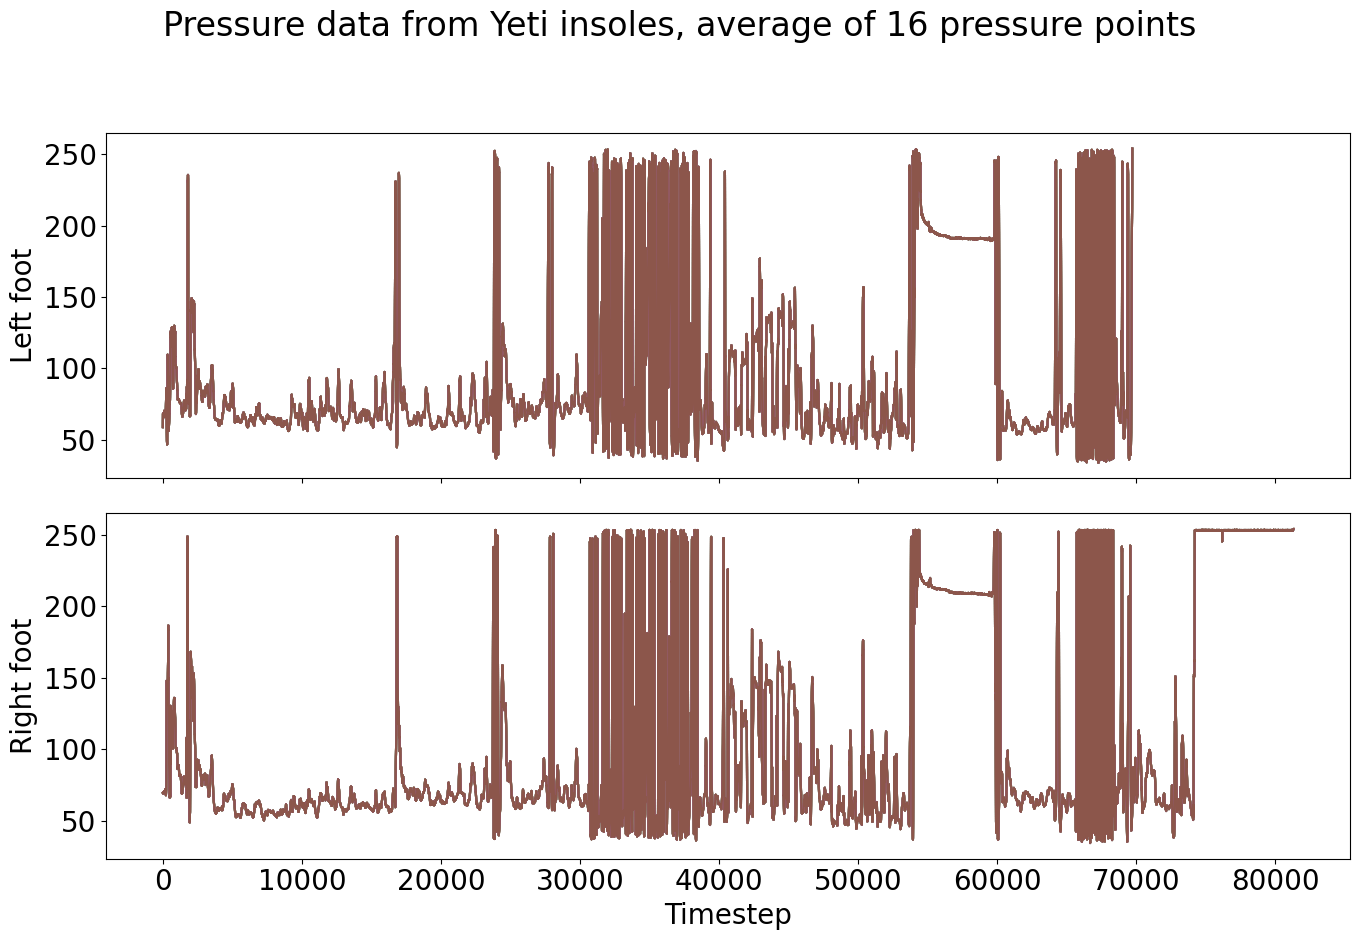

MARIA TEST FILES


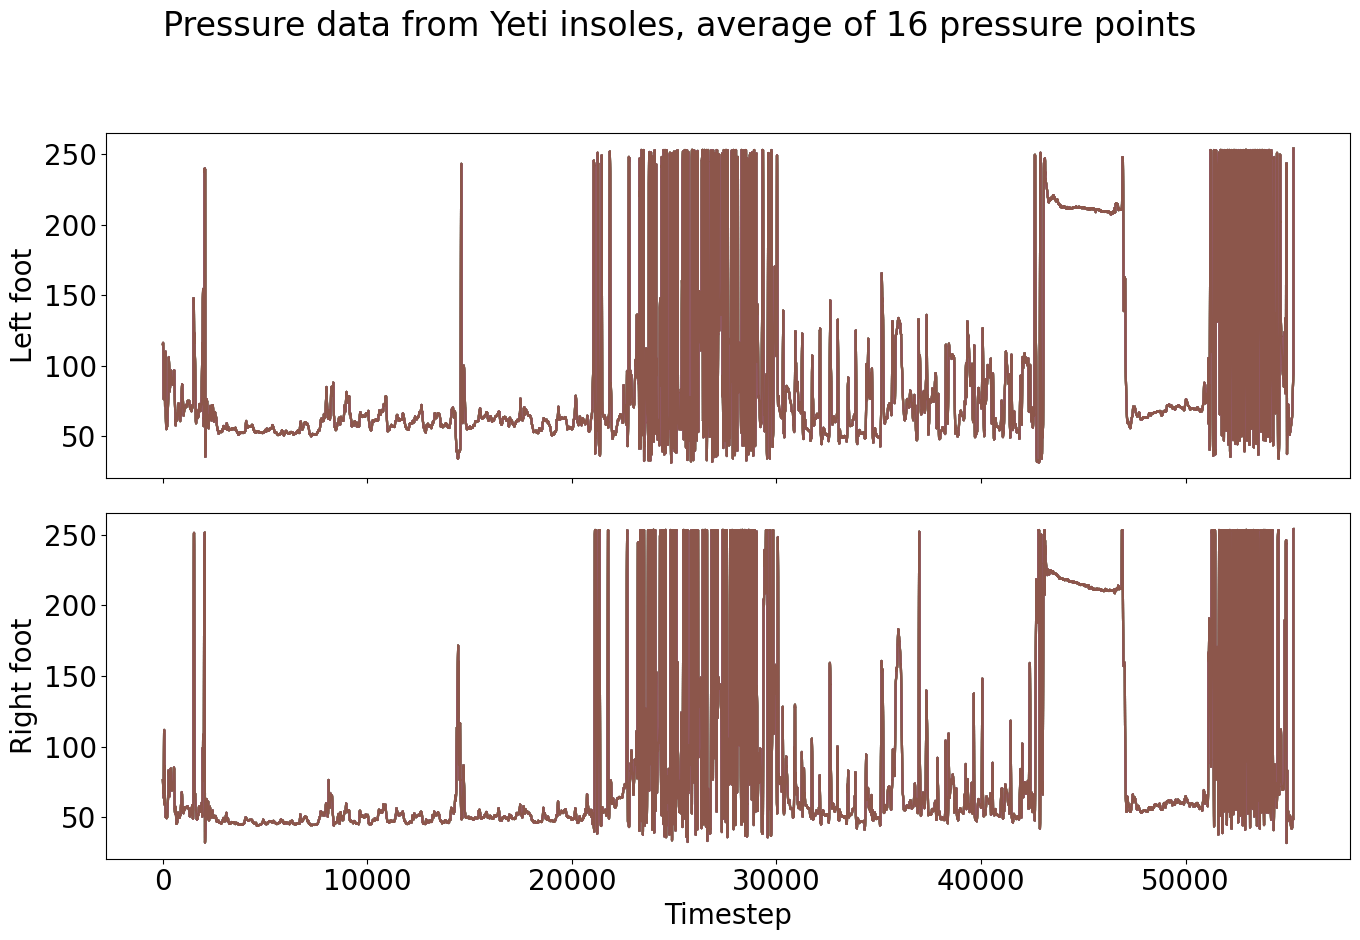

In [34]:
# MITCH PRESSURE COMPARISONS
# convert mitch .txt files to df list
left_df_j = pd.read_csv(raw_left_path, delimiter="\t", skiprows=8, decimal=",")
right_df_j = pd.read_csv(raw_right_path, delimiter="\t", skiprows=8, decimal=",")

left_df_m = pd.read_csv(maria_left, delimiter="\t", skiprows=8, decimal=",")
right_df_m = pd.read_csv(maria_right, delimiter="\t", skiprows=8, decimal=",")

list_j = [left_df_j, right_df_j, None, None]
list_m = [left_df_m, right_df_m, None, None]

print(left_df_j.min(), left_df_m.max())

print("JOHANNE TEST FILES")
preassure_plots_average(list_j)

print("MARIA TEST FILES")
preassure_plots_average(list_m)


In [ ]:
# plot back data as well


### Fix time for IMU sensor data

In [35]:
df_list = make_df(muse_file_1=raw_arm_path, muse_file_2=raw_back_path) # a list containing one element in this case...
samples, time = check_samples(df_list)

print("Samples:", samples)
print("Time:", time)

fix_time_muse_hz(df_list, 0, raw_arm_path, 800) # 800 is the sampling frequency
fix_time_muse_hz(df_list, 1, raw_back_path, 800) # 800 is the sampling frequency

# New .csv is saved to directory where the raw sensor data file resides.

Samples: [544484, 544484, None, None, None, None]
Time: [11.345316666666667, 11.3454, None, None, None, None]


'Time is fixed with hz and new files made'

### Detect spikes, init labelling and plot

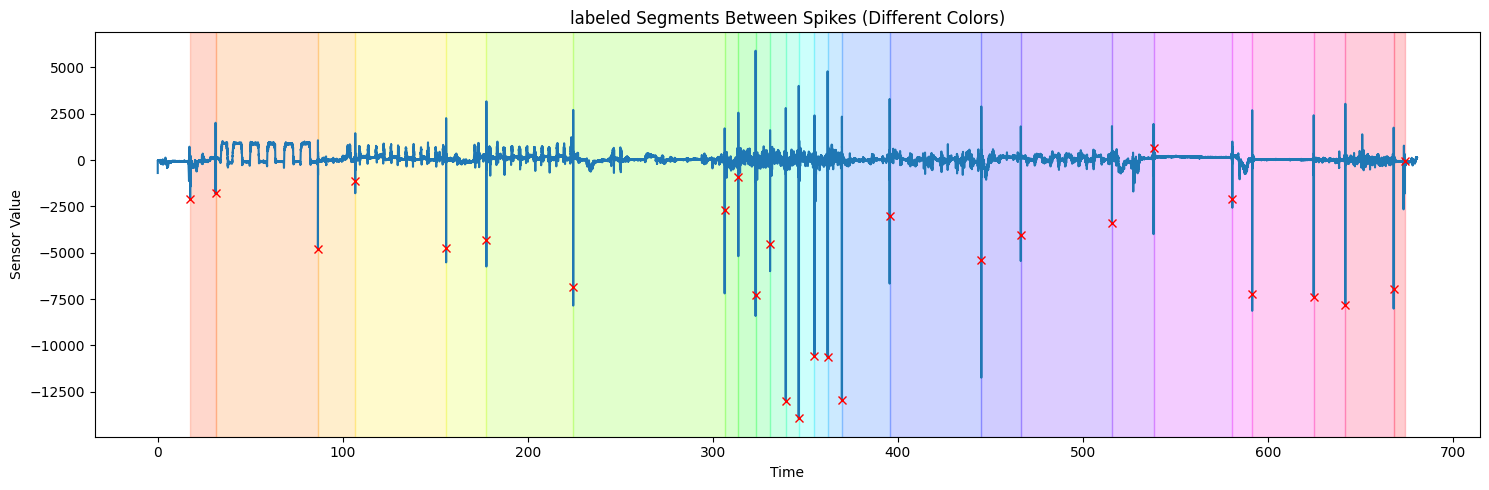

In [2]:
# TODO: paste file directory for fixed time file into the variable fixed_time_arm_path
fixed_time_arm_path = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_master_maria\test_6\Muse_E2511_RED-upper_arm_new_time_hz.csv"
fixed_time_back_path = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_master_maria\test_6\Muse_E2511_GREY-lower_back_new_time_hz.csv"

peak_df, peaks = detect_spikes(fixed_time_arm_path)
init_label_df = init_label(peak_df, peaks, fixed_time_arm_path)
plot_signal_peaks(init_label_df, peaks) 

Take a look at the generated plot. See that it makes sense wrt. the number of repetitions and peaks. Sometimes some peaks will have to be filtered away. Do so below and label again if necessary. 

Note that all the cells below must be run regardless of filtering away peaks or not.


### Activity -> correct label map
Can be altered to account for irregularities in the activity set. For instance if one extra push/pull rep is done...

In [3]:
# define rename map
rename_map = {
    "Activity_2": "hand_up_back",
    "Activity_4": "hands_forward",
    "Activity_6": "hands_up",
    "Activity_8": "push_1",
    "Activity_9": "pull_1",
    "Activity_10": "push_2",
    "Activity_11": "pull_2",
    "Activity_12": "push_3",
    "Activity_13": "pull_3",
    "Activity_14": "push_4",
    "Activity_15": "pull_4",
    # "Activity_16": "push_5",
    # "Activity_17": "pull_5",
    # "Activity_18":"push_6",
    # "Activity_19":"pull_6",
    "Activity_17": "squatting", 
    "Activity_19": "lifting",
    "Activity_21": "sitting",
    "Activity_23": "standing",
    "Activity_25": "walking",
}

In [80]:
print(peaks)

[ 14021  24993  69255  85396 124697 142099 179644 245106 251031 258488
 264755 271527 277124 283954 289621 295793 316442 356090 373144 412574
 430552 464622 473214 499788 513479 534365 539068]


{'label': 'idle', 'Start Time (s)': '17.52625', 'End Time (s)': '31.24125'}
{'label': 'hand_up_back', 'Start Time (s)': '31.24125', 'End Time (s)': '86.56875000000001'}
{'label': 'idle', 'Start Time (s)': '86.56875000000001', 'End Time (s)': '106.745'}
{'label': 'hands_forward', 'Start Time (s)': '106.745', 'End Time (s)': '155.87125'}
{'label': 'idle', 'Start Time (s)': '155.87125', 'End Time (s)': '177.62375'}
{'label': 'hands_up', 'Start Time (s)': '177.62375', 'End Time (s)': '224.555'}
{'label': 'idle', 'Start Time (s)': '224.555', 'End Time (s)': '306.3825'}
{'label': 'push_1', 'Start Time (s)': '306.8825', 'End Time (s)': '313.78875'}
{'label': 'pull_1', 'Start Time (s)': '314.28875', 'End Time (s)': '323.11'}
{'label': 'push_2', 'Start Time (s)': '323.61', 'End Time (s)': '330.94375'}
{'label': 'pull_2', 'Start Time (s)': '331.44375', 'End Time (s)': '339.40875'}
{'label': 'push_3', 'Start Time (s)': '339.90875', 'End Time (s)': '346.40500000000003'}
{'label': 'pull_3', 'Start 

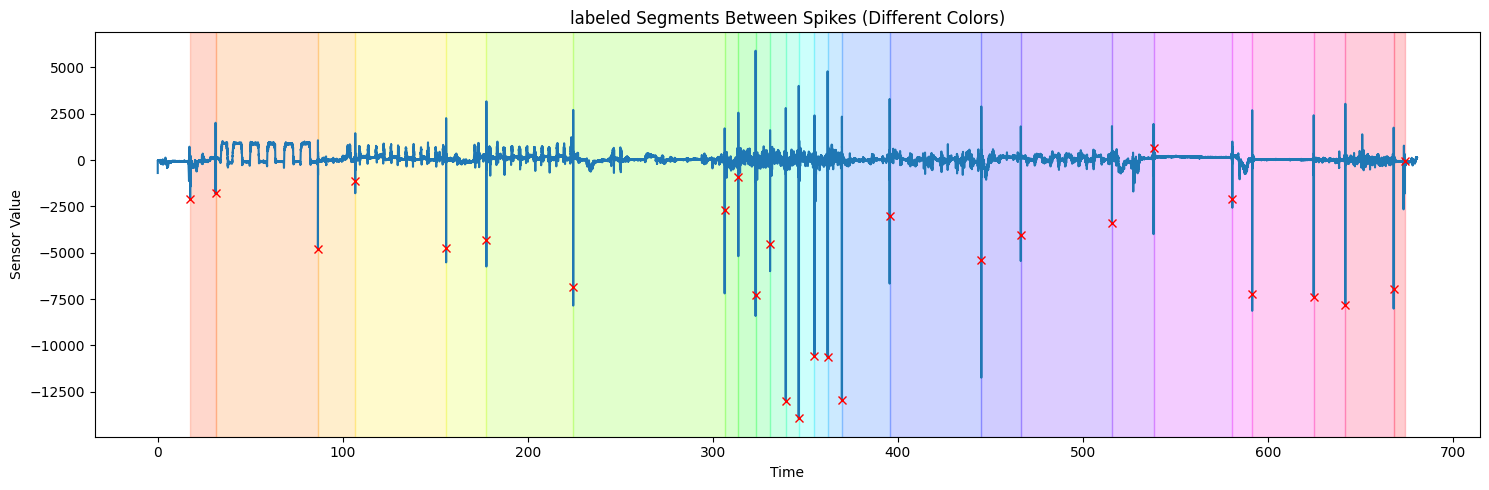

,Timestamp,Gyr.X,Gyr.Y,Gyr.Z,Axl.X,Axl.Y,Axl.Z,Hdr.X,Hdr.Y,Hdr.Z,Mag.X,Mag.Y,Mag.Z,ReconstructedTime,acc_mag,label,rep_id
0,1746559038994,7.420,-4.830,29.750,-700.768,-188.368,745.66400,811.924560,-1206.48840,-1271.810500,0,-100254,0,0.00000,1040.467729,idle,idle
1,1746559038995,-9.065,4.480,-2.765,-25.376,813.008,127.85600,26.304253,-516.44010,-117.492325,-2254,980,-294,0.00125,823.391223,idle,idle
2,1746559038997,-61.740,36.085,-49.910,-41.480,969.656,151.28000,25.427444,-526.96185,-109.601050,686,1470,-588,0.00250,982.262178,idle,idle
3,1746559038998,27.125,27.440,-28.245,-34.160,969.656,152.74400,24.550636,-521.70100,-110.916260,588,2156,-490,0.00375,982.206900,idle,idle
4,1746559038999,20.720,-2.450,0.385,-29.768,963.800,157.62401,27.181060,-516.44010,-114.423500,294,1960,-196,0.00500,977.057778,idle,idle


In [4]:


add_peak =  142881  + 60*800

#manually_filtered_peaks = peaks
# if no peaks need be removed, otherwise:

# code for adding a peak where none was detected

manually_filtered_peaks = []
#manually_filtered_peaks = [] # potentially manually select which peaks to keep here
drop_peaks = [] # define which peaks to drop here

for i in range(0, len(peaks)):
    peak = peaks[i]
    # if peak == 142881:
    #     manually_filtered_peaks.append(peak)
    #     print("adding the extra peak behind", peak)
    #     manually_filtered_peaks.append(add_peak)
    
    if i in drop_peaks:
        print(f"dropping peak num {i}")
        continue
    else:
        manually_filtered_peaks.append(peaks[i])



rows = []
push_idx = 1
pull_idx = 1
for i in range(len(manually_filtered_peaks) - 1):
    start_t = float(init_label_df["ReconstructedTime"].iloc[manually_filtered_peaks[i]]) 
    end_t   = float(init_label_df["ReconstructedTime"].iloc[manually_filtered_peaks[i+1]])
    
    # also add a 'rep_id' column to df
    init_label_df["rep_id"] = "idle" 
    
    try:
        if 'push' in rename_map[f"Activity_{i+1}"]:
            label = rename_map[f"Activity_{i+1}"]
            push_idx += 1
            start_t = start_t + 0.5 # filter away spikes at the beginning of push pull segments

            
        elif 'pull' in rename_map[f"Activity_{i+1}"]:
            label = rename_map[f"Activity_{i+1}"]
            pull_idx += 1
            start_t = start_t + 0.5

        else:
            label = rename_map[f"Activity_{i+1}"]
    except:
        label = "idle"
    rows.append({
        "label": label,
        "Start Time (s)": str(start_t),
        "End Time (s)": str(end_t)
    })
    

# Sanity check: see if start stop times for each label is correct. Compare plot x-axis with the printed start stop times.
for item in rows:
    print(item)
plot_signal_peaks(init_label_df, manually_filtered_peaks)

init_label_df.head()

If everything looks good, proceed to concatenate and save...


In [5]:
start_stop_df = pd.DataFrame(rows)

# Drop idle rows
start_stop_df = start_stop_df.drop(start_stop_df[start_stop_df['label'] == 'idle'].index)

start_stop_df.to_csv(output_dir / "start_stop_labels.csv")

# label both arm and back files
_, labeled_arm_path = apply_corrected_labels(new_time_file=fixed_time_arm_path, start_stop_csv_path=output_dir / "start_stop_labels.csv")
_, labeled_back_path = apply_corrected_labels(new_time_file=fixed_time_back_path, start_stop_csv_path=output_dir / "start_stop_labels.csv")

NameError: name 'output_dir' is not defined

In [85]:
start_stop_df

,label,Start Time (s),End Time (s)
1,hand_up_back,31.24125,86.56875000000001
3,hands_forward,106.745,155.87125
5,hands_up,177.62375,224.555
7,push_1,306.8825,313.78875
8,pull_1,314.28875,323.11
9,push_2,323.61,330.94375
10,pull_2,331.44375,339.40875
11,push_3,339.90875,346.40500000000003
12,pull_3,346.90500000000003,354.9425
13,push_4,355.4425,362.02625


### Label Mitch data
(Also includes dropping end duplicates and adding ReconstructedTime)


Basically the exact same as Maria's run_label_mitch.py file.

read filepath: C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_master_maria\test_6\mitch_B0308-left_old_small.txt
output path C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_master_maria\test_6\mitch_B0308-left_old_small_del_end_dupli.csv
read filepath: C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_master_maria\test_6\mitch_B0510-right_new_small.txt
output path C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_master_maria\test_6\mitch_B0510-right_new_small_del_end_dupli.csv
69712
81290


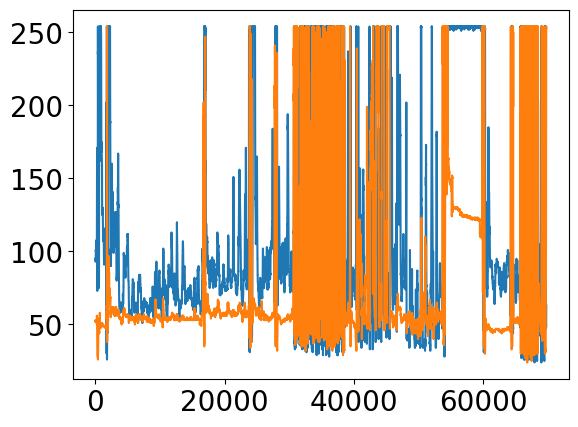

In [86]:
df_dupli_left, outpath_dupli_left = remove_end_duplicates(raw_left_path)
df_dupli_right, outpath_dupli_right = remove_end_duplicates(raw_right_path)

print(len(df_dupli_left))
print(len(df_dupli_right))

df_dupli_right = df_dupli_right[:len(df_dupli_left)]

plt.plot(df_dupli_right['Fsr.01'])
plt.plot(df_dupli_left['Fsr.01'])

In [87]:
# df_dupli_left, outpath_dupli_left = remove_end_duplicates(raw_left_path)
# df_dupli_right, outpath_dupli_right = remove_end_duplicates(raw_right_path)


df_time_left, outpath_time_left = add_ReconstructedTime(outpath_dupli_left, df_dupli_left)
df_time_right, outpath_time_right = add_ReconstructedTime(outpath_dupli_right, df_dupli_right)

df_time_left['ReconstructedTime'] = df_time_right['ReconstructedTime']

df_label_left, outpath_label_left = apply_corrected_labels(outpath_time_left, output_dir / "start_stop_labels.csv", df_time_left)
df_label_right, outpath_label_right = apply_corrected_labels(outpath_time_right, output_dir / "start_stop_labels.csv", df_time_right)

df_fsr_left, outpath_fsr_left = extract_pressure_data(outpath_label_left, df_label_left)
df_fsr_right, outpath_fsr_right = extract_pressure_data(outpath_label_right, df_label_right)

Sample number: 69712
Recorded time sec: 1115.845
Recorded time min: 18.597416666666668
Sample number: 69712
Recorded time sec: 680.381
Recorded time min: 11.339683333333333


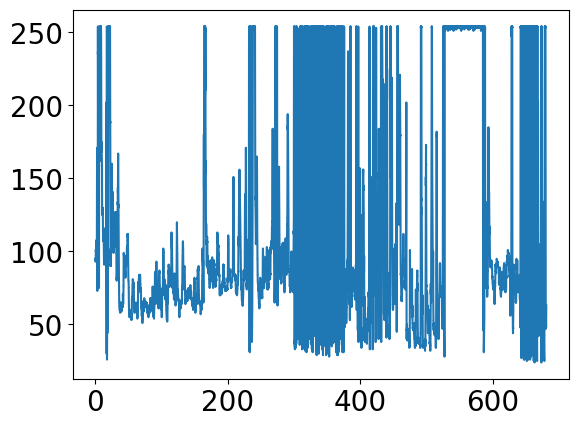

right reconstr. time length 69712
left reconstr. time length 69712


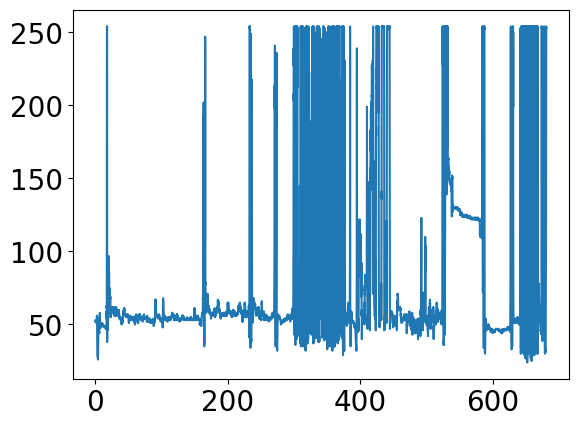

In [88]:


#df_fsr_right['ReconstructedTime'] = df_fsr_left['ReconstructedTime'][:len(df_fsr_right)]
plt.plot(df_fsr_right['ReconstructedTime'], df_fsr_right['Fsr.01'])
plt.show()



#df_fsr_left['ReconstructedTime'] = df_fsr_right['ReconstructedTime']

plt.plot(df_fsr_left['ReconstructedTime'], df_fsr_left['Fsr.01'])


print("right reconstr. time length", len(df_fsr_right['ReconstructedTime']))
print("left reconstr. time length", len(df_fsr_left['ReconstructedTime']))

### Drop idle for all sensors

In [89]:
df_left_no_idle, outpath_left_no_idle = remove_idle(correct_label_filepath=outpath_label_left, correct_label_df=df_label_left)
df_right_no_idle, outpath_right_no_idle = remove_idle(correct_label_filepath=outpath_label_right, correct_label_df=df_label_right)
df_arm_no_idle, outpath_arm_no_idle = remove_idle(correct_label_filepath=labeled_arm_path)
df_back_no_idle, outpath_back_no_idle = remove_idle(correct_label_filepath=labeled_back_path)

#### If you have already done the preprocessing and wanna jump straight to segmentation, copy your no idle paths in below, and dataframes will be creted from them :))

In [2]:
outpath_arm_no_idle = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_17\Muse_E2511_RED-arm_new_time_hz_labeled_no_idle.csv"
outpath_back_no_idle = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_17\Muse_E2511_GREY-back_new_time_hz_labeled_no_idle.csv"
outpath_left_no_idle = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_17\mitch_B0308-old_left_big_del_end_dupli_new_time_labeled_no_idle.csv"
outpath_right_no_idle = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_17\mitch_B0510-new_right_big_del_end_dupli_new_time_labeled_no_idle.csv"

output_dir =Path(r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_17")

### Apply median filter for all sensors and drop IMU columns from Mitch files

Kernel sizes: 21 for Muse sensors, 9 for mitch. Reasoning found in Maria's master's thesis, where different kernel sizes were tested.

In [3]:
imu_columns = ["Axl.X", "Axl.Y", "Axl.Z",
               "Gyr.X", "Gyr.Y", "Gyr.Z",
               "Mag.X", "Mag.Y", "Mag.Z"]

fsr_columns = [f"Fsr.{str(sensor).zfill(2)}" for sensor in range(1, 17)]

df_filtered_arm, path_arm_filtered = median_filter_medfilt(outpath_arm_no_idle, imu_columns, kernel_size=21)
df_filtered_back, path_back_filtered = median_filter_medfilt(outpath_back_no_idle, imu_columns, kernel_size=21)

#df_filtered_left, path_left_filtered = median_filter_medfilt(outpath_left_no_idle, fsr_columns, 9)
#df_filtered_right, path_right_filtered = median_filter_medfilt(outpath_right_no_idle, fsr_columns, 9)

# df_filtered_left = df_filtered_left.drop(columns=imu_columns)
# df_filtered_right = df_filtered_right.drop(columns=imu_columns)

# df_filtered_left.to_csv(f"{path_left_filtered.rstrip('.csv')}_drop_imu.csv")
# df_filtered_right.to_csv(f"{path_right_filtered.rstrip('.csv')}_drop_imu.csv")


#before_filter_df = pd.read_csv(outpath_right_no_idle)

# # compare pressure data before and after.
# for fsr in fsr_columns:
#     plt.figure(figsize=(12, 6))  # ⬅️ wider figure (increase first number)
#     plt.plot(before_filter_df['ReconstructedTime'], before_filter_df[fsr], label='Before Filter')
#     plt.plot(df_filtered_right['ReconstructedTime'], df_filtered_right[fsr], label='After Filter')
#     plt.xlabel('Time')

#     plt.ylabel(f'Pressure {fsr}')
#     plt.legend()
#     plt.title('Comparison of fsr data before and after median filter')
#     plt.show()

### Find repetition IDs


##### Sanity check: same start, stop times in all reconstructed times?

In [8]:
dfs = [df_filtered_arm, df_filtered_back, df_filtered_left, df_filtered_right]

for df in dfs:
    RT_list = df['ReconstructedTime'].to_list()
    print("Start time", RT_list[0])
    print("Stop time", RT_list[-1])

Start time 40.33
Stop time 1018.75
Start time 40.33
Stop time 1018.75
Start time 40.33623527625986
Stop time 1018.7535124468732
Start time 40.33625020395
Stop time 1018.7538894685918


#### Rep id methodology:
- Extract windows of single activities
- Treat each activity one by one

hand_up_back
- plot all accelerations plus acceleration mag on arm sensor
- detect spikes in acceleration magnitude
- look at plots and filter away spikes that are mistakes, i.e. that don't align with the larger acceleration transients.

hands_forward

same as hand  back

hands_up
same as hand back

squatting
- use filtered back df and detect spikes in  accel Y



#### Switch the activity_label argument to the desired one below and run through
#### 🚨 Remember to switch to back dataframe for squatting and lifting movements🚨


In [ ]:
# For test_14, define paths to the combined paths here:
# combining happened after the old 'dummy rep_id' part, so all filtering is done as well...
arm = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_14\Muse_E2511_RED-arm_comined_ppsorted.csv"
back = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_14\Muse_E2511_GREY-back_combined_ppsorted.csv"
left = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_14\mitch_B0308-big-left_combined_ppsorted.csv"
right = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_14\mitch_B0510-big-right_combined_ppsorted.csv"

df_filtered_arm = pd.read_csv(arm)
df_filtered_back = pd.read_csv(back)
df_filtered_left = pd.read_csv(left)
df_filtered_right = pd.read_csv(right)



C:\Users\Bruker\AppData\Local\Temp\ipykernel_34196\2445224128.py:8: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df_filtered_arm = pd.read_csv(arm)
C:\Users\Bruker\AppData\Local\Temp\ipykernel_34196\2445224128.py:9: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df_filtered_back = pd.read_csv(back)


Local: [   79  2555  6103  8917 12866]
Original: Index([93343, 95819, 99367, 102181, 106130], dtype='int64')


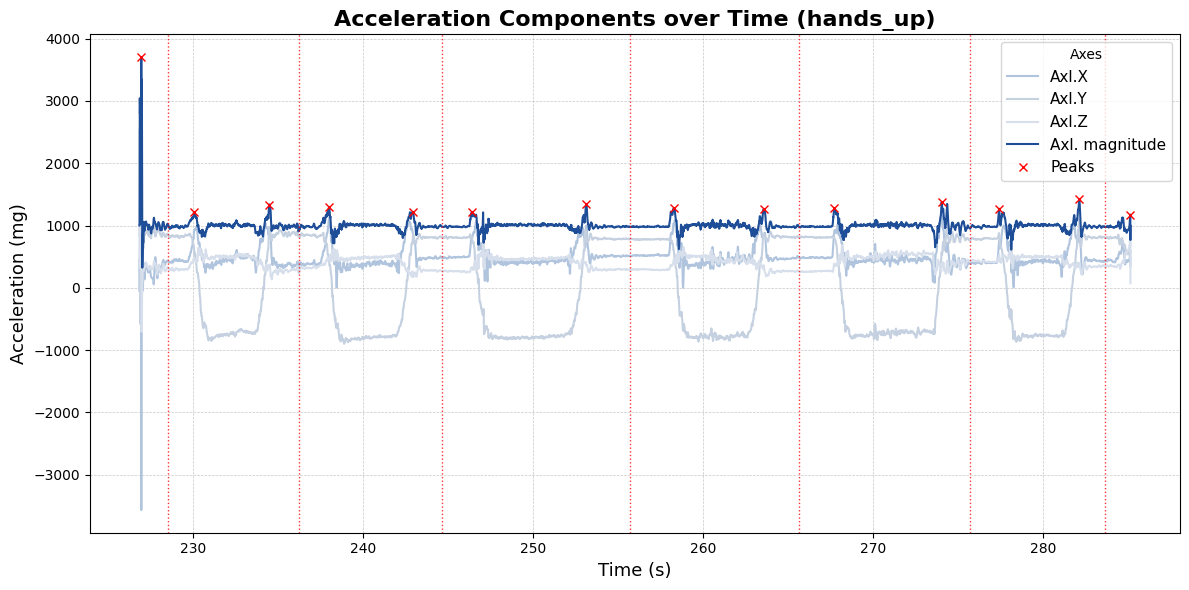

In [4]:
# we use the arm df from the previous cell
activity_label = 'hands_up'
_, peaks, peaks_mask = plot_activity_accelerations_peaks_and_magnitude(df_filtered_arm, activity_label, height=1100, distance=1100)

In [234]:
# investigate the peaks
peaks

Index([42002, 44619, 48131, 50473, 53735, 56210, 59681, 62534, 63802, 66249,
       68680, 72098, 74294, 77064, 78335],
      dtype='int64')

In [ ]:
# Manually alter the peaks such that the peaks can be used to differentiate between 
drop_peaks = [2, 6, 8, 10, 12, 13]
filtered_peaks = []
filtered_peaks_original = []
for i in range(len(peaks_mask)):
    # if i == 5 or i == 6 or i == 7 or i == 8:
    #     filtered_peaks.append(peaks_mask[i] - 5*800) # approx seconds in samples
    #     filtered_peaks_original.append(peaks[i] - 5*800)
    
    if i == 0:
        filtered_peaks.append(peaks_mask[i] - 1*800)
        filtered_peaks_original.append(peaks[i]- 1*800)
    
    # if i == 5:
    #     filtered_peaks.append(peaks_mask[i] - 3*800)
    #     filtered_peaks_original.append(peaks[i]- 3*800)
        
    
  
    
    if i not in drop_peaks:
        filtered_peaks.append(peaks_mask[i])
        filtered_peaks_original.append(peaks[i])
        
    # if i == 7:
    #     filtered_peaks.append(peaks_mask[i] + 4*800)
    #     filtered_peaks_original.append(peaks[i] +4*800)
    
        

#add the end peak, if it is not there... adjust how far after the last detected peak it should be  
# last_mask = int(peaks_mask[-1])
# last_orig = int(peaks[-1])
# filtered_peaks.append(int(last_mask) + 1*800)
# filtered_peaks_original.append(int(last_orig) + 1*800)

In [ ]:
filtered_peaks_original

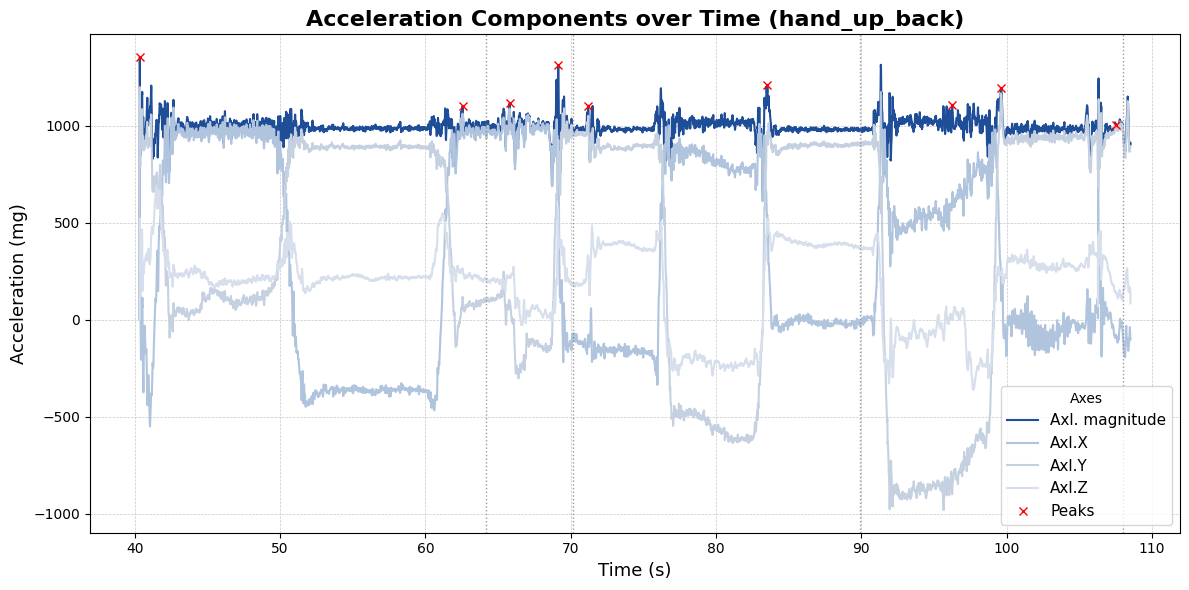

(           Timestamp    Gyr.X    Gyr.Y   Gyr.Z    Axl.X       Axl.Y  \
 0      1747242694114    0.000    0.000   0.000    0.000    0.000000   
 1      1747242694116    0.000    0.000   0.000    0.000    0.000000   
 2      1747242694117   82.460    0.000   0.000    0.000   43.920002   
 3      1747242694118   94.325    0.000   0.000    0.000  102.480000   
 4      1747242694119   94.325    0.000   0.000    0.000  393.816000   
 ...              ...      ...      ...     ...      ...         ...   
 54550  1747242762313   -4.375   18.375  16.240 -101.504  894.504000   
 54551  1747242762314   -4.375   18.375  16.275 -101.504  894.504000   
 54552  1747242762316   -4.375    9.205  16.520 -101.504  894.504000   
 54553  1747242762317   -4.130 -230.300  16.695 -101.504  893.040040   
 54554  1747242762318  209.160 -230.300  18.830 -101.504  892.552000   
 
             Axl.Z       Hdr.X      Hdr.Y       Hdr.Z  Mag.X  Mag.Y  Mag.Z  \
 0        0.000000  116.615520 -286.71634   73.213500   

In [11]:
# plot again to see that everything aligns

plot_activity_accelerations_peaks_and_magnitude(df_filtered_arm, activity_label, peak_indices=filtered_peaks)

In [ ]:
len(filtered_peaks) == len(filtered_peaks_original)

In [261]:
# Split in the middle between last and first peak
even = []
odd = []
even_orig = []
odd_orig = []
for i in range(len(filtered_peaks)):
    if i % 2 == 0:
        # print(f'adding index {i} to EVEN')
        # print('second mark is', df_filtered_back['ReconstructedTime'].iloc[int(filtered_peaks_original[i])])
        even.append(filtered_peaks[i])
        even_orig.append(filtered_peaks_original[i])
    else:
        # print(f'adding index {i} to ODD')
        # print('second mark is', df_filtered_back['ReconstructedTime'].iloc[int(filtered_peaks_original[i])])
        odd.append(filtered_peaks[i])
        odd_orig.append(filtered_peaks_original[i])

print(even_orig)
print(odd_orig)
filtered_peaks_original = [] # clear the list
for i in range(len(odd_orig)):
    first = even_orig[i]
    second = odd_orig[i]
    # print(first,second)
    # print("In time")
    # print(df_filtered_back['ReconstructedTime'].iloc[int(first)], df_filtered_back['ReconstructedTime'].iloc[int(second)],)
    print((first + second) // 2)
    # segment at middle point between even and odd peak, i.e. last of prev rep and first of next rep:
    
    filtered_peaks_original.append((first + second) // 2) 

print("splits seconds marks")
for idx in filtered_peaks_original:
    print(df_filtered_back['ReconstructedTime'].iloc[int(idx)])   
    
    

[np.int64(114886), np.int64(118715), np.int64(124440), np.int64(130306), np.int64(139537), np.int64(148065), np.int64(154230)]
[np.int64(115686), np.int64(122337), np.int64(127284), np.int64(135605), np.int64(145449), np.int64(152654), np.int64(156140)]
115286
120526
125862
132955
142493
150359
155185
splits seconds marks
326.84125
333.39125
340.06125000000003
348.9275
360.85
370.6825
376.715


#### Save the repetitions start stop times to a .csv-file
Below, the df is also visualized. Check that the timestamps correspond with the plot above:)

In [12]:
print(filtered_peaks_original)
start_stop_reps_dict, start_stop_reps_df = get_start_stop_times_from_peaks(df_filtered_back, filtered_peaks_original, activity_label, num_reps=6)
start_stop_reps_df.to_csv(output_dir / f'start_stop_rep_times_{activity_label}.csv')


NameError: name 'filtered_peaks_original' is not defined

In [265]:
# check that df makes sense
start_stop_reps_df

,rep_id,start_time,stop_time
0,squatting_1,326.84125,333.39125
1,squatting_2,333.39125,340.06125
2,squatting_3,340.06125,348.92750
3,squatting_4,348.92750,360.85000
4,squatting_5,360.85000,370.68250
5,squatting_6,370.68250,376.71500


#### Seconds based segmenting for sitting, standing, walking

NOTE FOR FUTURE USE: This was redone after completion of labelling and cleaning the first time around and is therefore done on the 
'..._ppsorted_cleaned.csv'-files. This was due to deciding to resample everything to a fixed length after having completed manual segmentation. Best practice would be to do this at the same stage as finding every other rep_id, i.e. use df_filtered_{sensor_name} instead of getting the already labelled and cleaned dfs from files.

(the old approach was segmenting into five varying length segments...)


In [22]:
from data_analysis.get_paths import get_test_file_paths
import pandas as pd
import matplotlib.pyplot as plt

LABELED_PATHS = get_test_file_paths()
test_id = 'test_6'

df_already_labeled_arm = pd.read_csv(LABELED_PATHS[test_id]['arm'])
df_already_labeled_back = pd.read_csv(LABELED_PATHS[test_id]['back'])
df_already_labeled_left = pd.read_csv(LABELED_PATHS[test_id]['left'])
df_already_labeled_right = pd.read_csv(LABELED_PATHS[test_id]['right'])

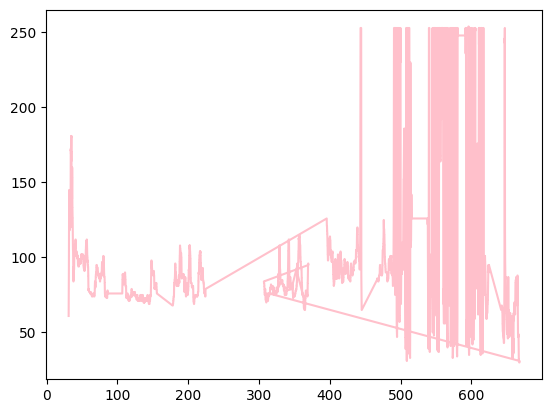

In [24]:
plt.plot(df_already_labeled_left['ReconstructedTime'], df_already_labeled_left['Fsr.09'], color='pink')
#plt.plot(df_already_labeled_right['ReconstructedTime'], df_already_labeled_right['Fsr.09'], color='blue')


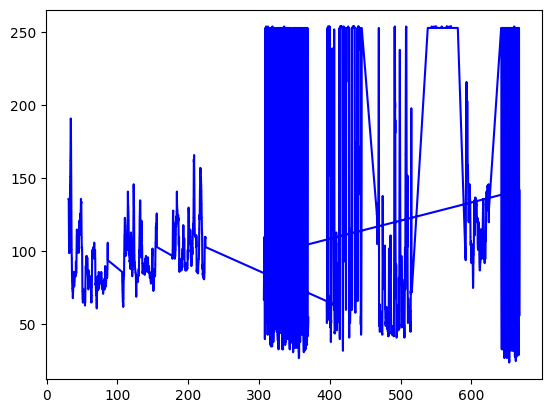

In [25]:
plt.plot(df_already_labeled_right['ReconstructedTime'], df_already_labeled_right['Fsr.09'], color='blue')

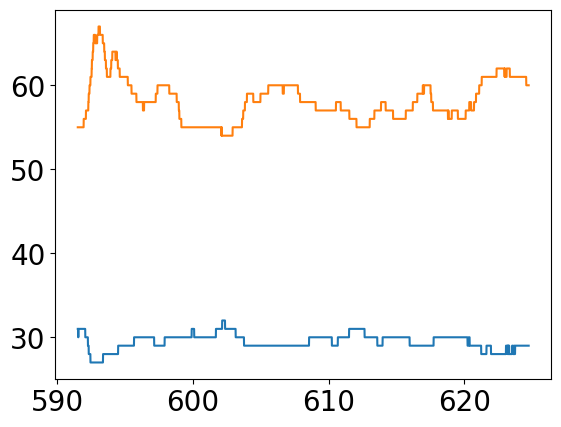

In [ ]:
activity_label = 'sitting'
# NOTE: make sure rep lengths are consistent with target number of samples during feature extraction
rep_length_samples_muse = 2800 #3,5 sec
rep_length_samples_mitch = 350 #3,5 sec

# Extract single activity from all dfs
activity_df_arm = df_filtered_arm[df_filtered_arm['label'] == activity_label]
activity_df_back = df_filtered_back[df_filtered_back['label'] == activity_label]
activity_df_left = df_filtered_left[df_filtered_left['label'] == activity_label]
activity_df_right = df_filtered_right[df_filtered_right['label'] == activity_label]

if not (len(activity_df_arm) == len(activity_df_back)) or not (len(activity_df_left) == len(activity_df_right)):
    print("mismatch between lengths of dfs")
    print("arm", len(activity_df_arm))
    print("back", len(activity_df_back))
    print("left", len(activity_df_left))
    print("right", len(activity_df_right))
    
    print("ReconstructedTime for the left sensor", activity_df_left['ReconstructedTime'].iloc[-1])
    print("ReconstructedTime for the left sensor", activity_df_right['ReconstructedTime'].iloc[-1])
    
# plt.plot(activity_df_right['ReconstructedTime'], activity_df_right['Fsr.09'])
# plt.plot(activity_df_left['ReconstructedTime'], activity_df_left['Fsr.09'])
# plt.show()

skip_seconds = 1 # Optionally skip first second to avoid initial spikes, typically from the arm tap 

# for IMU use arm df
t0 = activity_df_arm['ReconstructedTime'].iloc[0]
activity_df_arm = activity_df_arm[activity_df_arm['ReconstructedTime'] >= (t0 + skip_seconds)].reset_index(drop=True)


# for FSR use left df
t0 = activity_df_left['ReconstructedTime'].iloc[0]
activity_df_left= activity_df_left[activity_df_left['ReconstructedTime'] >= (t0 + skip_seconds)].reset_index(drop=True)





#### Now, add a rep_id column to each sensor dataframe based on start stop times


In [92]:
import time
arm_df = df_filtered_arm.copy()
back_df = df_filtered_back.copy()
left_df = df_filtered_left.copy()
right_df = df_filtered_right.copy()

#init the rep id col
arm_df['rep_id'] = arm_df['label']
back_df['rep_id'] = back_df['label']
left_df['rep_id'] = left_df['label']
right_df['rep_id'] = right_df['label']


for df in [arm_df, back_df, left_df, right_df]:
    mask = df["label"].str.contains("push|pull", case=False, na=False)
    df.loc[~mask, "rep_id"] = None


activities =  arm_df['label'].unique().tolist() # get all possible labels
print(activities)
time.sleep(10)
for activity in activities:
    if 'push' in activity or 'pull' in activity:
        for df in [arm_df, back_df, left_df, right_df]:
            mask = df["label"].str.contains("push|pull", case=False, na=False)
             # Simplify label to just "push" or "pull"
            df.loc[mask, "label"] = (
                df.loc[mask, "label"]
                .str.extract(r"(push|pull)", expand=False)
                .str.lower()
            )

        print("✅ Assigned rep_ids and reset push/pull labels to base activity names")
    else:
        rep_start_stop_time_path = output_dir / f"start_stop_rep_times_{activity}.csv"
        start_stop_df = pd.read_csv(rep_start_stop_time_path)
        
         # For each repetition in that CSV
        for _, rep in start_stop_df.iterrows():
            rep_id = rep["rep_id"]
            start_time = rep["start_time"]
            stop_time  = rep["stop_time"]

            # Loop through each dataframe (arm, back, left, right)
            for df in [arm_df, back_df, left_df, right_df]:
                # Create mask for rows that fall within this rep's time window
                mask = (
                    (df["label"] == activity)
                    & (df["ReconstructedTime"] >= start_time)
                    & (df["ReconstructedTime"] < stop_time)
                )
                df.loc[mask, "rep_id"] = rep_id
                print(df)

        print(f"✅ Assigned rep_ids for {activity}")
        

['hand_up_back', 'hands_forward', 'hands_up', 'push_1', 'pull_1', 'push_2', 'pull_2', 'push_3', 'pull_3', 'push_4', 'pull_4', 'squatting', 'lifting', 'sitting', 'standing', 'walking']
            Timestamp   Gyr.X   Gyr.Y  Gyr.Z   Axl.X      Axl.Y    Axl.Z  \
0       1746559070241   0.000 -15.365  0.000   0.000    0.00000    0.000   
1       1746559070242  50.190 -20.230  0.000   0.000    0.00000    0.000   
2       1746559070243  51.730 -37.730  0.000   0.000  491.90400    0.000   
3       1746559070244  65.065 -43.925  0.000   0.000  509.47202    0.000   
4       1746559070246  74.375 -43.925  0.000   0.000  534.36000    0.000   
...               ...     ...     ...    ...     ...        ...      ...   
329230  1746559707060 -19.565 -49.350  6.545  87.352  876.93604  227.896   
329231  1746559707062 -19.250 -49.350  6.300  85.400  875.47200  226.432   
329232  1746559707062 -18.760 -49.350  6.090   0.000  873.52000    0.000   
329233  1746559707064 -18.480 -49.350  5.740   0.000  87

In [93]:
add_rep_paths = {'arm': path_arm_filtered.replace('.csv', '_add_rep_ids.csv'),
                 'back' : path_back_filtered.replace('.csv', '_add_rep_ids.csv'),
                 'left' : path_left_filtered.replace('.csv', '_drop_imu_add_rep_ids.csv'),
                 'right' : path_right_filtered.replace('.csv', '_drop_imu_add_rep_ids.csv')}

arm_df.to_csv(add_rep_paths['arm'])
back_df.to_csv(add_rep_paths['back'])
left_df.to_csv(add_rep_paths['left'])
right_df.to_csv(add_rep_paths['right'])



### Sort push and pull

In [94]:
for _,path in add_rep_paths.items():
    sort_push_pull(path)

## Finished! 🎉
Go over output directory and delete unnecessary .csv files. (the ones with _ppsorted suffix are the ones we will keep using)
Add the correct paths to the get_paths.py - file

-----> Next step is **FEATURE EXTRACTION**

In [ ]:
# Special case for when sensor cut out midway....

#define paths
arm_rep_id_25 = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_25\Muse_E2511_RED-arm_new_time_hz_labeled_no_idle_median_filter_add_rep_ids.csv"
back_rep_id_25 = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_25\Muse_E2511_GREY-back_new_time_hz_labeled_no_idle_median_filter_add_rep_ids.csv"
left_rep_id_25 = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_25\mitch_B0308-lef_del_end_dupli_new_time_labeled_no_idle_median_filter_drop_imu_add_rep_ids.csv"
right_rep_id_25 = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_25\mitch_B0510-righ_del_end_dupli_new_time_labeled_no_idle_median_filter_drop_imu_add_rep_ids.csv"

arm_rep_id_16 = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_19\Muse_E2511_RED-arm_new_time_hz_labeled_no_idle_median_filter_add_rep_ids.csv"
back_rep_id_16 = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_19\Muse_E2511_GREY-back_new_time_hz_labeled_no_idle_median_filter_add_rep_ids.csv"
left_rep_id_16 = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_19\mitch_B0308-big_lef_del_end_dupli_new_time_labeled_no_idle_median_filter_drop_imu_add_rep_ids.csv"
right_rep_id_16 = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_19\mitch_B0510-big_righ_del_end_dupli_new_time_labeled_no_idle_median_filter_drop_imu_add_rep_ids.csv"

df_arm_16 = pd.read_csv(arm_rep_id_16)
df_back_16 = pd.read_csv(back_rep_id_16)
df_left_16 = pd.read_csv(left_rep_id_16)
df_right_16 = pd.read_csv(right_rep_id_16)

df_arm_25 = pd.read_csv(arm_rep_id_25)
df_back_25 = pd.read_csv(back_rep_id_25)
df_left_25 = pd.read_csv(left_rep_id_25)
df_right_25 = pd.read_csv(right_rep_id_25)

static_16_arm = df_arm_16[df_arm_16['label'].isin(['sitting', 'standing', 'walking'])]
static_16_back = df_back_16[df_back_16['label'].isin(['sitting', 'standing', 'walking'])]
static_16_left = df_left_16[df_left_16['label'].isin(['sitting', 'standing', 'walking'])]
static_16_right= df_right_16[df_right_16['label'].isin(['sitting', 'standing', 'walking'])]

drop_labels = ['sitting', 'standing', 'walking']

df_arm_25 = df_arm_25[~df_arm_25['label'].isin(drop_labels)]
df_left_25 = df_left_25[~df_left_25['label'].isin(drop_labels)]
df_right_25 = df_right_25[~df_right_25['label'].isin(drop_labels)]

combined_arm = pd.concat([df_arm_25, static_16_arm])
combined_back = pd.concat([df_back_25, static_16_back])
combined_left = pd.concat([df_left_25, static_16_left])
combined_right = pd.concat([df_right_25, static_16_right])

combined_arm


In [ ]:
numeric_cols = combined_right.select_dtypes(include="number").columns
for col in numeric_cols:
    if "fsr.01" in col.lower():
        plt.plot(combined_right["ReconstructedTime"], combined_right[col], label=col)

plt.xlabel("ReconstructedTime")
plt.ylabel("Sensor Value")
#plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Save combined dfs to csv
out_dir = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_johanne\test_19"

out_arm = Path(out_dir) / "Muse_E2511_RED-arm_comined.csv"
out_back = Path(out_dir) / "Muse_E2511_GREY-back_combined.csv"
out_left = Path(out_dir) / "mitch_B0308-big-left_combined.csv"
out_right = Path(out_dir) / "mitch_B0510-big-right_combined.csv"

combined_arm.to_csv(out_arm)
combined_back.to_csv(out_back)
combined_left.to_csv(out_left)
combined_right.to_csv(out_right)

combined_paths = [str(out_arm), str(out_back), str(out_left), str(out_right)]



In [ ]:
for path in combined_paths:
    sort_push_pull(path)

In [ ]:
df = pd.read_csv(f"{str(out_right).replace('.csv', '')}_ppsorted.csv")

df